# Aerospace Flight-Control SIL Project
This notebook implements a complete Software-in-the-Loop simulation for a 1-DOF pitch axis. It includes simulated rigid-body physics, a noisy IMU sensor, a Mahony attitude estimator, and a cascaded PID controller.


## 1. Imports and Configuration


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Simulation configuration and physical constants
DT = 0.001           # 1 kHz simulation rate
SIM_TIME = 10.0      # 10 seconds total

# Rigid Body Plant (Pitch Axis)
INERTIA_YY = 0.05    # kg*m^2
DAMPING = 0.01       # N*m*s/rad
TAU_MAX = 1.0        # Max actuator torque (N*m)

# IMU Sensor Simulation (Fault Injection Configurable)
GYRO_BIAS = 0.0174   # ~1.0 deg/s bias
GYRO_STD = 0.005     # rad/s noise
ACCEL_STD = 0.05     # m/s^2 noise
GRAVITY = 9.81

# Mahony Estimator
MAHONY_KP = 2.0
MAHONY_KI = 0.05
INIT_PITCH_ERROR = 0.523 # Fault: Initial estimator attitude error (30 degrees)

# Cascaded PID Controller
ANGLE_KP, ANGLE_KI, ANGLE_KD = 8.0, 0.5, 0.0
MAX_PITCH_RATE = 3.14 # rad/s
RATE_KP, RATE_KI, RATE_KD = 1.2, 0.2, 0.02

@dataclass
class IMUData:
    gyro: np.ndarray  # [gx, gy, gz] rad/s
    accel: np.ndarray # [ax, ay, az] m/s^2



## 2. Plant and Sensor Simulation


In [2]:
class PitchPlant:
    """1-DOF Rigid Body Pitch Dynamics."""
    def __init__(self, inertia, damping, tau_max):
        self.I = inertia
        self.c = damping
        self.tau_max = tau_max
        self.pitch = 0.0
        self.pitch_rate = 0.0

    def update(self, torque, dt):
        torque = np.clip(torque, -self.tau_max, self.tau_max)
        alpha = (torque - self.c * self.pitch_rate) / self.I
        self.pitch_rate += alpha * dt
        self.pitch += self.pitch_rate * dt
        return self.pitch, self.pitch_rate

class IMUSensor:
    """Simulates an IMU with noise, bias, and gravity rotation."""
    def __init__(self, gyro_bias, gyro_std, accel_std, g):
        self.gyro_bias = gyro_bias
        self.gyro_std = gyro_std
        self.accel_std = accel_std
        self.g = g

    def get_measurement(self, true_pitch, true_pitch_rate):
        ax = -self.g * np.sin(true_pitch) + np.random.normal(0, self.accel_std)
        ay = np.random.normal(0, self.accel_std)
        az = self.g * np.cos(true_pitch) + np.random.normal(0, self.accel_std)

        gx = np.random.normal(0, self.gyro_std)
        gy = true_pitch_rate + self.gyro_bias + np.random.normal(0, self.gyro_std)
        gz = np.random.normal(0, self.gyro_std)
        return IMUData(gyro=np.array([gx, gy, gz]), accel=np.array([ax, ay, az]))



## 3. Mahony Attitude Estimator


In [3]:
class MahonyFilter:
    """Lightweight nonlinear attitude estimator using quaternions."""
    def __init__(self, kp, ki, dt, initial_pitch=0.0):
        self.kp = kp
        self.ki = ki
        self.dt = dt
        half_p = initial_pitch / 2.0
        self.q = np.array([np.cos(half_p), 0.0, np.sin(half_p), 0.0])
        self.e_int = np.array([0.0, 0.0, 0.0])
        self.estimated_rate = 0.0

    def update(self, imu: IMUData):
        norm_a = np.linalg.norm(imu.accel)
        if norm_a == 0: return self.get_pitch(), self.estimated_rate

        a = imu.accel / norm_a
        qw, qx, qy, qz = self.q

        v = np.array([
            2.0 * (qx * qz - qw * qy),
            2.0 * (qy * qz + qw * qx),
            qw**2 - qx**2 - qy**2 + qz**2
        ])

        e = np.cross(a, v)
        self.e_int += e * self.dt

        omega = imu.gyro + self.kp * e + self.ki * self.e_int
        self.estimated_rate = omega[1]

        qw_dot = -0.5 * (qx*omega[0] + qy*omega[1] + qz*omega[2])
        qx_dot =  0.5 * (qw*omega[0] + qy*omega[2] - qz*omega[1])
        qy_dot =  0.5 * (qw*omega[1] - qx*omega[2] + qz*omega[0])
        qz_dot =  0.5 * (qw*omega[2] + qx*omega[1] - qy*omega[0])

        self.q += np.array([qw_dot, qx_dot, qy_dot, qz_dot]) * self.dt
        self.q /= np.linalg.norm(self.q)

        return self.get_pitch(), self.estimated_rate

    def get_pitch(self):
        qw, qx, qy, qz = self.q
        val = np.clip(2.0 * (qw * qy - qz * qx), -1.0, 1.0)
        return np.arcsin(val)



## 4. Cascaded PID Controller


In [4]:
class PID:
    def __init__(self, kp, ki, kd, limit, dt):
        self.kp, self.ki, self.kd = kp, ki, kd
        self.limit = limit
        self.dt = dt
        self.integral = 0.0
        self.prev_error = 0.0

    def update(self, error):
        self.integral += error * self.dt
        self.integral = np.clip(self.integral, -self.limit, self.limit)

        derivative = (error - self.prev_error) / self.dt
        self.prev_error = error

        out = self.kp * error + self.ki * self.integral + self.kd * derivative
        return float(np.clip(out, -self.limit, self.limit))

class CascadedController:
    def __init__(self, dt, max_rate, max_torque, angle_gains, rate_gains):
        self.angle_pid = PID(*angle_gains, limit=max_rate, dt=dt)
        self.rate_pid = PID(*rate_gains, limit=max_torque, dt=dt)

    def update(self, desired_pitch, est_pitch, est_rate):
        angle_error = desired_pitch - est_pitch
        desired_rate = self.angle_pid.update(angle_error)

        rate_error = desired_rate - est_rate
        torque = self.rate_pid.update(rate_error)
        return torque



## 5. Main Simulation & Plotting


   SIL VALIDATION RESULTS
Estimator RMSE:        4.837 deg
Max Estimation Error:  29.911 deg

Rise Time:             0.770 s
Overshoot:             0.00 %
Settling Time:         3.000 s
Steady-State Error:    0.307 deg
RMS Control Effort:    0.447 Nm


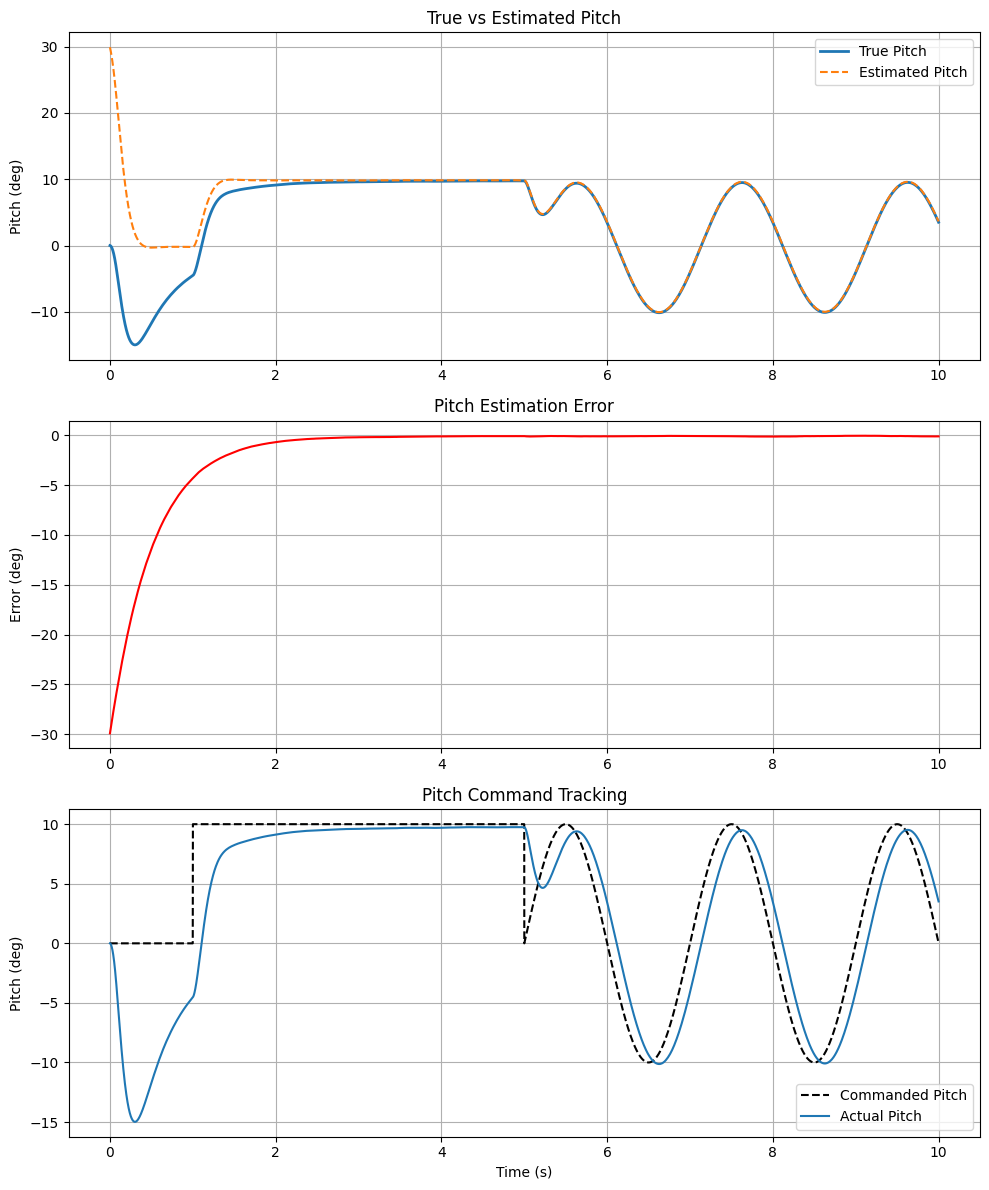

In [5]:
def compute_metrics(t, ref, est, actual, control):
    ref_deg, est_deg, actual_deg = np.rad2deg(ref), np.rad2deg(est), np.rad2deg(actual)
    rmse_est = np.sqrt(np.mean((actual_deg - est_deg)**2))
    max_est_err = np.max(np.abs(actual_deg - est_deg))

    step_mask = (t >= 1.0) & (t <= 4.0)
    y_step = actual_deg[step_mask]
    t_step = t[step_mask] - 1.0
    target = 10.0

    rise_time, overshoot, settling_time = 0.0, 0.0, 0.0
    if len(y_step) > 0:
        try:
            t_10 = t_step[np.where(y_step >= 0.1 * target)[0][0]]
            t_90 = t_step[np.where(y_step >= 0.9 * target)[0][0]]
            rise_time = t_90 - t_10
        except IndexError: pass
        overshoot = max(0.0, (np.max(y_step) - target) / target * 100.0)
        outside_bounds = np.where(np.abs(y_step - target) > 0.02 * target)[0]
        if len(outside_bounds) > 0: settling_time = t_step[outside_bounds[-1]]

    ss_error = np.mean(np.abs(target - y_step[-100:])) if len(y_step) > 100 else 0.0
    rms_effort = np.sqrt(np.mean(control**2))
    return rmse_est, max_est_err, rise_time, overshoot, settling_time, ss_error, rms_effort

def run_simulation():
    plant = PitchPlant(INERTIA_YY, DAMPING, TAU_MAX)
    imu = IMUSensor(GYRO_BIAS, GYRO_STD, ACCEL_STD, GRAVITY)
    estimator = MahonyFilter(MAHONY_KP, MAHONY_KI, DT, INIT_PITCH_ERROR)
    controller = CascadedController(DT, MAX_PITCH_RATE, TAU_MAX,
        (ANGLE_KP, ANGLE_KI, ANGLE_KD), (RATE_KP, RATE_KI, RATE_KD))

    t_arr, ref_arr, true_arr, est_arr, u_arr = [], [], [], [], []
    true_pitch, true_rate = 0.0, 0.0

    for step in range(int(SIM_TIME / DT)):
        t = step * DT

        # Reference Trajectory
        if t < 1.0: desired_pitch = 0.0
        elif t < 5.0: desired_pitch = np.deg2rad(10.0)
        else: desired_pitch = np.deg2rad(10.0) * np.sin(2 * np.pi * 0.5 * (t - 5.0))

        # SIL Pipeline
        imu_data = imu.get_measurement(true_pitch, true_rate)
        est_pitch, est_rate = estimator.update(imu_data)
        torque = controller.update(desired_pitch, est_pitch, est_rate)
        true_pitch, true_rate = plant.update(torque, DT)

        # Log
        t_arr.append(t); ref_arr.append(desired_pitch); true_arr.append(true_pitch)
        est_arr.append(est_pitch); u_arr.append(torque)

    t_arr, ref_arr, true_arr = np.array(t_arr), np.array(ref_arr), np.array(true_arr)
    est_arr, u_arr = np.array(est_arr), np.array(u_arr)

    # Metrics
    metrics = compute_metrics(t_arr, ref_arr, est_arr, true_arr, u_arr)
    print(f"==============================\n   SIL VALIDATION RESULTS\n==============================")
    print(f"Estimator RMSE:        {metrics[0]:.3f} deg\nMax Estimation Error:  {metrics[1]:.3f} deg\n")
    print(f"Rise Time:             {metrics[2]:.3f} s\nOvershoot:             {metrics[3]:.2f} %")
    print(f"Settling Time:         {metrics[4]:.3f} s\nSteady-State Error:    {metrics[5]:.3f} deg")
    print(f"RMS Control Effort:    {metrics[6]:.3f} Nm\n==============================")

    # Plots
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    axes[0].plot(t_arr, np.rad2deg(true_arr), label='True Pitch', lw=2)
    axes[0].plot(t_arr, np.rad2deg(est_arr), '--', label='Estimated Pitch')
    axes[0].set_title('True vs Estimated Pitch')
    axes[0].set_ylabel('Pitch (deg)')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(t_arr, np.rad2deg(true_arr - est_arr), color='red')
    axes[1].set_title('Pitch Estimation Error')
    axes[1].set_ylabel('Error (deg)')
    axes[1].grid(True)

    axes[2].plot(t_arr, np.rad2deg(ref_arr), 'k--', label='Commanded Pitch')
    axes[2].plot(t_arr, np.rad2deg(true_arr), label='Actual Pitch')
    axes[2].set_title('Pitch Command Tracking')
    axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Pitch (deg)')
    axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# Run it
run_simulation()

